# Importing Library

## Pip install thing (just to shorten the installation log)

In [30]:
# !pip install --user tensorflow==2.17
# !pip install --user opencv-python
# !pip install --user matplotlib
# !pip install --user tensorflow-hub
# !pip install --user scikit-learn
# !pip install --user numpy==1.26.4 
# !pip install --user seaborn


## Importing Library

### Run this if you're on Jupyter Lab

In [33]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import os
import seaborn as sns
import glob
import cv2
import zipfile
from tensorflow.keras import layers, models
from tensorflow.keras import Model, Input
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential  # Sequential API for building models layer by layer
from tensorflow.keras.utils import to_categorical
import shutil
from PIL import Image
import hashlib
import random
from pathlib import Path
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

print("TF version:", tf.__version__)
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")
# Check for GPU availability in TensorFlow
device = "GPU" if len(tf.config.list_physical_devices('GPU')) > 0 else "CPU"
print("The device is:", device)

# rm -rf '/content/__MACOSX'
# use this one when you need to remove folder and not getting must be empty error

TF version: 2.17.0
GPU is NOT AVAILABLE
The device is: CPU


# Extracting Data

### Loading and Unzipping Data From Drive

In [36]:
# Define the extraction paths
train_extract_path = 'dataset/train_images/'
test_extract_path = 'dataset/test_images/'

# For train images: remove if exists, then extract
if os.path.exists(train_extract_path):
    print(f"Removing existing train images folder: {train_extract_path}")
    shutil.rmtree(train_extract_path)
    
# Create directory if it doesn't exist
os.makedirs(train_extract_path, exist_ok=True)

# Extract train images
with zipfile.ZipFile('zip_data/train_images.zip', 'r') as train_zip_ref:
    print("Extracting train images...")
    train_zip_ref.extractall(train_extract_path)
    print("Train images extracted successfully.")

# For test images: remove if exists, then extract
if os.path.exists(test_extract_path):
    print(f"Removing existing test images folder: {test_extract_path}")
    shutil.rmtree(test_extract_path)
    
# Create directory if it doesn't exist
os.makedirs(test_extract_path, exist_ok=True)

# Extract test images
with zipfile.ZipFile('zip_data/test_images.zip', 'r') as test_zip_ref:
    print("Extracting test images...")
    test_zip_ref.extractall(test_extract_path)
    print("Test images extracted successfully.")

print("All extraction complete!")

Removing existing train images folder: dataset/train_images/
Extracting train images...
Train images extracted successfully.
Removing existing test images folder: dataset/test_images/
Extracting test images...
Test images extracted successfully.
All extraction complete!


### Check Class Names

In [38]:
CLASS_NAMES = [os.path.basename(l) for l in glob.glob('dataset/train_images/train_images/*')
               if '.' not in l]
# CLASS_NAMES = [os.path.basename(l) for l in glob.glob('/content/drive/MyDrive/Colab Notebooks/train_images/train_images/*')
#                if '.' not in l]  ## if on google colab
print(CLASS_NAMES)

['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']


### Load CSV file

In [40]:
# train_df = pd.read_csv('/content/drive/MyDrive/Dataset/meta_train.csv')
train_df = pd.read_csv('opencv/meta_train.csv')
train_df

,image_id,label,variety,age
0,100330.jpg,bacterial_leaf_blight,ADT45,45
1,100365.jpg,bacterial_leaf_blight,ADT45,45
2,100382.jpg,bacterial_leaf_blight,ADT45,45
3,100632.jpg,bacterial_leaf_blight,ADT45,45
4,101918.jpg,bacterial_leaf_blight,ADT45,45
...,...,...,...,...
10402,107607.jpg,tungro,Zonal,55
10403,107811.jpg,tungro,Zonal,55
10404,108547.jpg,tungro,Zonal,55
10405,110245.jpg,tungro,Zonal,55


Map the path depending on the label first

In [42]:
# train_df['path'] = '/content/drive/MyDrive/Colab Notebooks/train_images/' + train_df['label'] + "/" + train_df["image_id"]
train_df['path'] = 'dataset/train_images/train_images/' + train_df['label'] + "/" + train_df["image_id"]
train_df.head()

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...


# Data Loading and Preprocessing

### Check Duplicates in dataset

In [45]:
def calculate_hash(image_path):
    with Image.open(image_path) as img:
        return hashlib.md5(img.tobytes()).hexdigest()

def find_duplicates_in_dataset(root_folder):
    hashes = {}
    duplicates = []

    for subdir, _, files in os.walk(root_folder):
        for file in files:
            if file.lower().endswith(('.png', '.jpg')):
                path = os.path.join(subdir, file)
                try:
                    file_hash = calculate_hash(path)
                    if file_hash in hashes:
                        duplicates.append((path, hashes[file_hash]))
                    else:
                        hashes[file_hash] = path
                except Exception as e:
                    print(f"Error processing {file}: {e}")
    
    return duplicates
    
# Function to delete duplicate files, keeping only the first occurrence
def remove_duplicate_files(duplicates):
    removed_count = 0
    for duplicate_path, original_path in duplicates:
        try:
            # Check if file exists before attempting to remove
            if os.path.exists(duplicate_path):
                os.remove(duplicate_path)
                print(f"Removed: {duplicate_path}")
                removed_count += 1
            else:
                print(f"File not found: {duplicate_path}")
        except Exception as e:
            print(f"Error removing {duplicate_path}: {e}")
    
    return removed_count

duplicates = find_duplicates_in_dataset('dataset/train_images/train_images/')
for dup1, dup2 in duplicates:
    print(f"Duplicate found:\n -> {dup1}\n -> {dup2}\n")

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\100513.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\100169.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\103032.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\100133.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\104800.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\102353.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\105878.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\103344.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\106984.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\100998.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\107812.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\100635.jpg

Duplicate found:
 -> dataset/train_image

Then we will remove these dulpicate ones from the dataframe
Then we need to remove it from the dataset as well.

In [47]:
# Remove the duplicate files from the filesystem
if duplicates:
    removed_count = remove_duplicate_files(duplicates)
    print(f"\nRemoved {removed_count} duplicate image files")
else:
    print("No duplicates found.")

# If you also need to update your dataframe after removing files
if 'train_df' in locals() or 'train_df' in globals():
    # Extract ONLY the duplicate paths (not the originals) to remove from dataframe
    paths_to_remove = [duplicate_path for duplicate_path, original_path in duplicates]
    
    # Normalize paths to ensure consistent comparison
    train_df['path'] = train_df['path'].apply(os.path.normpath)
    paths_to_remove = [os.path.normpath(path) for path in paths_to_remove]
    
    # Remove only the duplicate entries from dataframe
    original_length = len(train_df)
    train_df = train_df[~train_df['path'].isin(paths_to_remove)].reset_index(drop=True)
    removed_count = original_length - len(train_df)
    
    print(f"Removed {removed_count} duplicate image entries from dataframe")

Removed: dataset/train_images/train_images/bacterial_leaf_blight\100513.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\103032.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\104800.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\105878.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\106984.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\107812.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\108125.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\108353.jpg
Removed: dataset/train_images/train_images/bacterial_panicle_blight\104803.jpg
Removed: dataset/train_images/train_images/blast\102705.jpg
Removed: dataset/train_images/train_images/blast\105626.jpg
Removed: dataset/train_images/train_images/blast\105840.jpg
Removed: dataset/train_images/train_images/blast\105962.jpg
Removed: dataset/train_images/train_images/blast\106520.jpg
Removed: data

### Sorted into folder according to their variety

In [49]:
# Define output base directory
output_base_dir = "dataset/train_images_by_exact_age"

# Reset output directory
if os.path.exists(output_base_dir):
    shutil.rmtree(output_base_dir)
    print(f"Removed existing directory: {output_base_dir}")

os.makedirs(output_base_dir, exist_ok=True)

# Get unique ages
ages = train_df["age"].unique()
print(f"Found {len(ages)} unique ages: {sorted(ages)}")

# Create directories for each age
for age in ages:
    age_dir = os.path.join(output_base_dir, f"{age}")
    os.makedirs(age_dir, exist_ok=True)

# Copy files to their new locations
print("Copying images to age folders...")
for idx, row in tqdm(train_df.iterrows(), total=len(train_df)):
    src_path = row["path"]
    dst_path = os.path.join(output_base_dir, f"{row['age']}", row['image_id'])

    try:
        shutil.copy2(src_path, dst_path)
    except FileNotFoundError:
        print(f"Warning: Could not find {src_path}")

print("Done. Images have been sorted into directories by exact age.")
print(f"New directory structure: {output_base_dir}/age/[image_id]")

# Count files in each age directory to verify
for age in ages:
    age_dir = os.path.join(output_base_dir, f"{age}")
    file_count = len([f for f in os.listdir(age_dir) if os.path.isfile(os.path.join(age_dir, f))])
    print(f"Age {age}: {file_count} images")


Found 18 unique ages: [45, 47, 50, 55, 57, 60, 62, 65, 66, 67, 68, 70, 72, 73, 75, 77, 80, 82]
Copying images to age folders...


100%|██████████████████████████████████████████████████████████████████████████| 10333/10333 [00:09<00:00, 1144.87it/s]


Done. Images have been sorted into directories by exact age.
New directory structure: dataset/train_images_by_exact_age/age/[image_id]
Age 45: 503 images
Age 50: 1054 images
Age 55: 560 images
Age 60: 1650 images
Age 65: 768 images
Age 68: 253 images
Age 70: 3059 images
Age 72: 543 images
Age 47: 112 images
Age 77: 42 images
Age 67: 411 images
Age 73: 38 images
Age 75: 857 images
Age 80: 225 images
Age 62: 5 images
Age 66: 36 images
Age 57: 212 images
Age 82: 5 images


### Map the csv depending on the age

In [51]:
train_df = train_df.drop('path', axis=1)
train_df['path'] = 'dataset/train_images_by_exact_age/' + train_df['age'].astype(str) + "/" + train_df["image_id"]
train_df.head()

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/100330.jpg
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/100365.jpg
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/100382.jpg
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/100632.jpg
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/101918.jpg


In [52]:
train_df

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/100330.jpg
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/100365.jpg
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/100382.jpg
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/100632.jpg
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_exact_age/45/101918.jpg
...,...,...,...,...,...
10328,107607.jpg,tungro,Zonal,55,dataset/train_images_by_exact_age/55/107607.jpg
10329,107811.jpg,tungro,Zonal,55,dataset/train_images_by_exact_age/55/107811.jpg
10330,108547.jpg,tungro,Zonal,55,dataset/train_images_by_exact_age/55/108547.jpg
10331,110245.jpg,tungro,Zonal,55,dataset/train_images_by_exact_age/55/110245.jpg


### Data Distribution

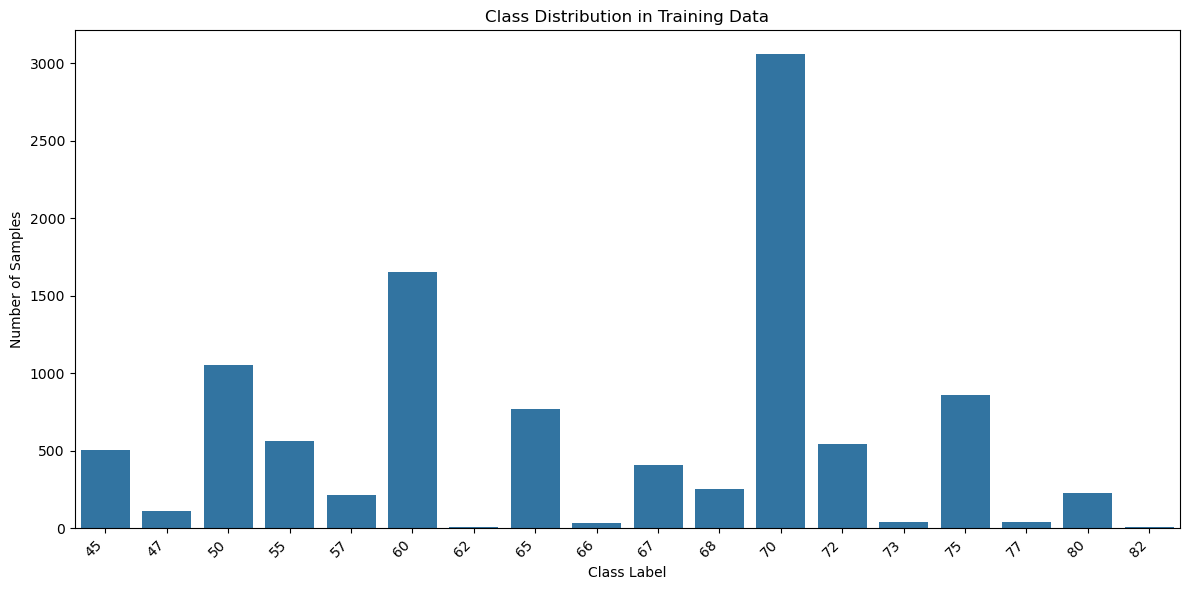

Class distribution:
70: 3059 samples (29.60%)
60: 1650 samples (15.97%)
50: 1054 samples (10.20%)
75: 857 samples (8.29%)
65: 768 samples (7.43%)
55: 560 samples (5.42%)
72: 543 samples (5.26%)
45: 503 samples (4.87%)
67: 411 samples (3.98%)
68: 253 samples (2.45%)
80: 225 samples (2.18%)
57: 212 samples (2.05%)
47: 112 samples (1.08%)
77: 42 samples (0.41%)
73: 38 samples (0.37%)
66: 36 samples (0.35%)
62: 5 samples (0.05%)
82: 5 samples (0.05%)


In [54]:
# Visualize class distribution
plt.figure(figsize=(12, 6))
class_counts = train_df['age'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution in Training Data')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print the exact counts
print("Class distribution:")
for age, count in class_counts.items():
    print(f"{age}: {count} samples ({count/len(train_df)*100:.2f}%)")

Add function to check the total count of image dataset

In [56]:
train_data_path = 'dataset/train_images_by_exact_age'

def check_total_images(data_dir):
    """
    Prints the number of images per class and the total in the dataset directory.
    """
    total = 0
    print("Image Count Per Class:")
    print("-" * 30)
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        count = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
        total += count
        print(f"{class_name:25}: {count} images")
    print("-" * 30)
    print(f"Total images in dataset: {total}")

check_total_images(train_data_path)

Image Count Per Class:
------------------------------
45                       : 503 images
47                       : 112 images
50                       : 1054 images
55                       : 560 images
57                       : 212 images
60                       : 1650 images
62                       : 5 images
65                       : 768 images
66                       : 36 images
67                       : 411 images
68                       : 253 images
70                       : 3059 images
72                       : 543 images
73                       : 38 images
75                       : 857 images
77                       : 42 images
80                       : 225 images
82                       : 5 images
------------------------------
Total images in dataset: 10333


## Augmentating the Data before Splitting and Loading

In [58]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

train_data_path = 'dataset/train_images_by_exact_age'

# Step 1: Count images per class
class_counts = {}
for class_name in os.listdir(train_data_path):
    class_path = os.path.join(train_data_path, class_name)
    if not os.path.isdir(class_path): continue
    image_files = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
    class_counts[class_name] = len(image_files)

# Step 2: Define augmentation
augmentor = ImageDataGenerator(
    rotation_range=20,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=(0.8, 1.2),
    horizontal_flip=True,
    fill_mode='nearest'
)

average_count = int(np.mean(list(class_counts.values())))
print(f"Target image count per class: {average_count}")

# Step 3: Augment classes below the average
for class_name, count in class_counts.items():
    if count >= average_count:
        print(f"Skipping '{class_name}' (already has {count} images)")
        continue

    class_path = os.path.join(train_data_path, class_name)
    images = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
    current_count = count
    augment_index = 0

    print(f"Augmenting '{class_name}' from {current_count} to {average_count}")
    pbar = tqdm(total=average_count - current_count)

    while current_count < average_count:
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            img = load_img(img_path)
            x = img_to_array(img).reshape((1,) + img_to_array(img).shape)

            batch = next(augmentor.flow(x, batch_size=1))
            new_img = array_to_img(batch[0])
            new_img.save(os.path.join(class_path, f'aug_{augment_index}.jpg'))

            current_count += 1
            augment_index += 1
            pbar.update(1)

            if current_count >= average_count:
                break

    pbar.close()


Target image count per class: 574
Augmenting '45' from 503 to 574


100%|██████████████████████████████████████████████████████████████████████████████████| 71/71 [00:06<00:00, 10.75it/s]


Augmenting '47' from 112 to 574


100%|████████████████████████████████████████████████████████████████████████████████| 462/462 [00:40<00:00, 11.34it/s]


Skipping '50' (already has 1054 images)
Augmenting '55' from 560 to 574


...

100%|████████████████████████████████████████████████████████████████████████████████| 532/532 [00:46<00:00, 11.44it/s]


Augmenting '80' from 225 to 574


100%|████████████████████████████████████████████████████████████████████████████████| 349/349 [00:32<00:00, 10.88it/s]


Augmenting '82' from 5 to 574


100%|████████████████████████████████████████████████████████████████████████████████| 569/569 [00:49<00:00, 11.59it/s]


### Data Normalization and Data Generator

In [60]:
check_total_images(train_data_path)

Image Count Per Class:
------------------------------
45                       : 574 images
47                       : 574 images
50                       : 1054 images
55                       : 574 images
57                       : 574 images
60                       : 1650 images
62                       : 574 images
65                       : 768 images
66                       : 574 images
67                       : 574 images
68                       : 574 images
70                       : 3059 images
72                       : 574 images
73                       : 574 images
75                       : 857 images
77                       : 574 images
80                       : 574 images
82                       : 574 images
------------------------------
Total images in dataset: 14850


In [61]:
BATCH_SIZE = 32
IMAGE_SHAPE = (224,224)
train_data_path = 'dataset/train_images_by_exact_age'

# For training data - with augmentation
data_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

In [62]:
# For training data (with augmentation)
train_gen = data_gen.flow_from_directory(
    train_data_path,
    target_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    subset='training',
    seed=42,
    class_mode='categorical',
    color_mode='rgb'
)

Found 11893 images belonging to 18 classes.


In [63]:
# For validation data (without augmentation)
valid_gen = data_gen.flow_from_directory(
    train_data_path,
    target_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    subset='validation',
    seed=42,
    class_mode='categorical',
    color_mode='rgb'
)

Found 2957 images belonging to 18 classes.


## Data Distribution After Augmentated

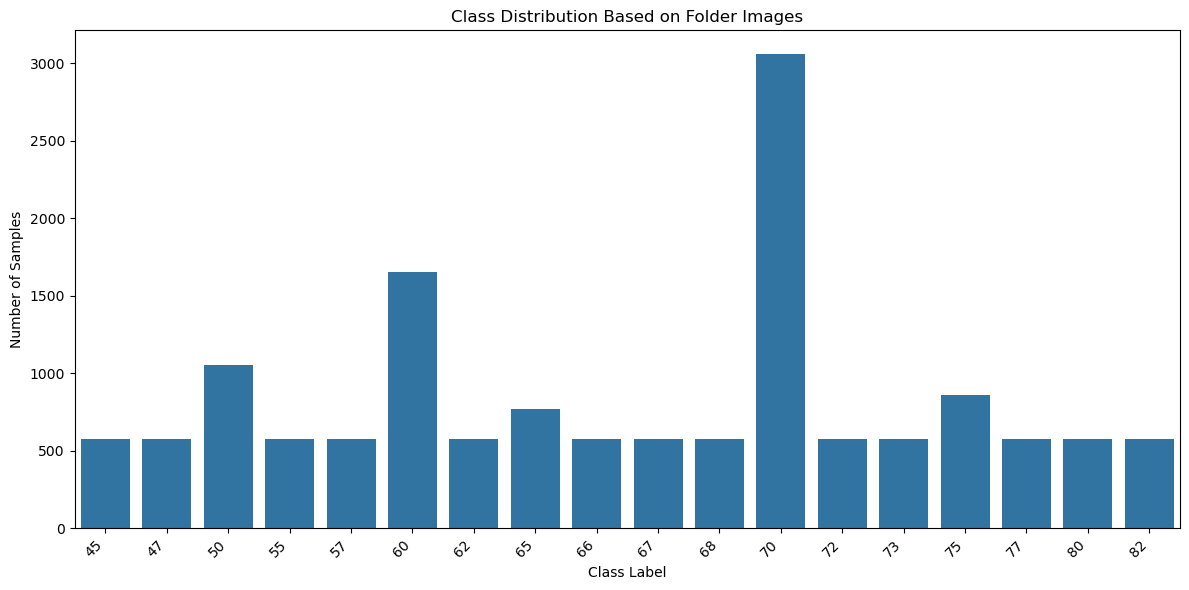

Updated Class Distribution:
45: 574 samples (3.87%)
47: 574 samples (3.87%)
50: 1054 samples (7.10%)
55: 574 samples (3.87%)
57: 574 samples (3.87%)
60: 1650 samples (11.11%)
62: 574 samples (3.87%)
65: 768 samples (5.17%)
66: 574 samples (3.87%)
67: 574 samples (3.87%)
68: 574 samples (3.87%)
70: 3059 samples (20.60%)
72: 574 samples (3.87%)
73: 574 samples (3.87%)
75: 857 samples (5.77%)
77: 574 samples (3.87%)
80: 574 samples (3.87%)
82: 574 samples (3.87%)


In [65]:
from collections import Counter

folder_counts = {}
for class_name in os.listdir(train_data_path):
    class_folder = os.path.join(train_data_path, class_name)
    if os.path.isdir(class_folder):
        count = len([f for f in os.listdir(class_folder) if f.endswith('.jpg')])
        folder_counts[class_name] = count

# Plot the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=list(folder_counts.keys()), y=list(folder_counts.values()))
plt.title('Class Distribution Based on Folder Images')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print counts
print("Updated Class Distribution:")
total_imgs = sum(folder_counts.values())
for label, count in folder_counts.items():
    print(f"{label}: {count} samples ({(count/total_imgs)*100:.2f}%)")

### Data Class Weighting

Calculate class weighting on the dataframe

In [68]:
def get_class_counts_from_folders(data_dir):
    """
    Returns a dictionary with image counts per class folder.
    """
    class_counts = {}
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        count = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
        class_counts[class_name] = count
    return class_counts

def calculate_class_weights(class_counts):
    """
    Calculates class weights inversely proportional to class frequencies.
    """
    total_samples = sum(class_counts.values())
    num_classes = len(class_counts)
    class_weights = {}

    for class_name, count in class_counts.items():
        class_weights[class_name] = total_samples / (num_classes * count)

    print("Class weights:")
    for class_name, weight in class_weights.items():
        print(f"Class '{class_name}': {weight:.4f}")

    return class_weights

def map_weights_to_generator_indices(class_weights, generator_class_indices):
    """
    Maps class weights (based on class names) to generator indices used during model training.
    """
    index_weights = {}

    for class_name, weight in class_weights.items():
        if class_name in generator_class_indices:
            index = generator_class_indices[class_name]
            index_weights[index] = weight
        else:
            print(f"Warning: Class '{class_name}' not found in generator indices")

    for class_name, index in generator_class_indices.items():
        if index not in index_weights:
            print(f"Warning: No weight assigned for generator class '{class_name}' (index {index})")

    return index_weights


In [69]:
# Step 1: Get counts directly from folders
class_counts = get_class_counts_from_folders(train_data_path)

# Step 2: Compute weights
class_weights = calculate_class_weights(class_counts)

# Step 3: Get generator class indices
generator_class_indices = train_gen.class_indices
print("Generator class indices:", generator_class_indices)

# Step 4: Map weights to generator indices
index_weights = map_weights_to_generator_indices(class_weights, generator_class_indices)

print("-" * 30)

# Final weights to use in model.fit()
print("Mapped index weights:")
for idx, weight in sorted(index_weights.items()):
    print(f"Index {idx}: {weight:.4f}")

Class weights:
Class '45': 1.4373
Class '47': 1.4373
Class '50': 0.7827
Class '55': 1.4373
Class '57': 1.4373
Class '60': 0.5000
Class '62': 1.4373
Class '65': 1.0742
Class '66': 1.4373
Class '67': 1.4373
Class '68': 1.4373
Class '70': 0.2697
Class '72': 1.4373
Class '73': 1.4373
Class '75': 0.9627
Class '77': 1.4373
Class '80': 1.4373
Class '82': 1.4373
Generator class indices: {'45': 0, '47': 1, '50': 2, '55': 3, '57': 4, '60': 5, '62': 6, '65': 7, '66': 8, '67': 9, '68': 10, '70': 11, '72': 12, '73': 13, '75': 14, '77': 15, '80': 16, '82': 17}
------------------------------
Mapped index weights:
Index 0: 1.4373
Index 1: 1.4373
Index 2: 0.7827
Index 3: 1.4373
Index 4: 1.4373
Index 5: 0.5000
Index 6: 1.4373
Index 7: 1.0742
Index 8: 1.4373
Index 9: 1.4373
Index 10: 1.4373
Index 11: 0.2697
Index 12: 1.4373
Index 13: 1.4373
Index 14: 0.9627
Index 15: 1.4373
Index 16: 1.4373
Index 17: 1.4373


### Callback Functions for training monitoring and improvement

In [71]:
class TerminateNaN(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        loss = logs.get('loss')
        if loss is not None:
            if np.isnan(loss) or np.isinf(loss):
                print(f"Invalid loss and terminated at loss {loss}; epoch: {epoch}")
                self.model.stop_training = True

terminate_nan = TerminateNaN()

In [72]:
# Save model after every epoch if the validation accuracy improves from previous epoch
cnn_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/task3_cnn_model.h5',
    monitor="val_categorical_accuracy",
    verbose=1,
    save_best_only=True,
    mode='auto',
    save_weights_only=False,
    save_freq='epoch'
)

inception_resnet_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/task3_inception_resnet_model.h5',
    monitor="val_categorical_accuracy",
    verbose=1,
    save_best_only=True,
    mode='auto',
    save_weights_only=False,
    save_freq='epoch'
)

In [73]:
# Standard learning rate reduction on plateau
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_categorical_accuracy",
    factor=0.1,
    patience=3,
    verbose=1,
    mode="auto",
    min_delta=0.001,
    cooldown=1,
    min_lr=1e-6
)

In [74]:
# Early stopping with baseline performance requirement
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_categorical_accuracy',
    min_delta=0.001,
    patience=10,
    verbose=1,
    mode='auto',
    baseline=None,  # Only consider stopping if accuracy is above this threshold
    restore_best_weights=True
)

In [75]:
# CSV logger to save training metrics to file
cnn_csv_logger = tf.keras.callbacks.CSVLogger(
    filename='logs/task3_cnn_training_history.csv',
    separator=',',
    append=True
)

mobile_net_csv_logger = tf.keras.callbacks.CSVLogger(
    filename='logs/task3_inception_resnet_training_history.csv',
    separator=',',
    append=True
)

### CNN Model

In [91]:
# For Task 3: Age Prediction (Regression)
cnn_model = models.Sequential([
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Third convolutional block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Additional convolutional block for more complex feature extraction
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),  # Add dropout to prevent overfitting
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Regression output - single neuron with linear activation
    layers.Dense(1)  # No activation function for regression (linear by default)
])

# Compile the model with regression metrics
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.MeanSquaredError(),  # MSE for regression
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mean_absolute_error"),  # MAE
        tf.keras.metrics.RootMeanSquaredError(name="root_mean_squared_error")  # RMSE
    ]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      25,690,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 26,149,313 (99.75 MB)

 Trainable params: 26,147,073 (99.74 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [ ]:
cnn_history = model.fit(
    train_gen,
    batch_size = batch_size,
    validation_data = valid_gen,
    epochs=100,
    verbose=1,
    class_weight=index_weights,
    callbacks=[terminate_nan, cnn_checkpoint, reduce_lr, early_stopping, cnn_csv_logger]
)

### Inception Resnet Model

In [95]:
# For Task 3: Advanced Model - Inception-ResNet with Multi-head Output
# IMAGE_SHAPE = (299, 299) - Standard size for InceptionResNetV2

# Input layer
input_tensor = Input(shape=(299, 299, 3))

# Data augmentation
x = layers.RandomFlip("horizontal")(input_tensor)
x = layers.RandomRotation(0.1)(x)
x = layers.RandomZoom(0.1)(x)

# Load the pre-trained InceptionResNetV2 model 
base_model = InceptionResNetV2(
    weights=None,
    include_top=False,
    input_tensor=x
)

# Keep all layers trainable since we're training from scratch
base_model.trainable = True

# Extract features
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
shared_features = layers.Dense(1024, activation='relu')(x)
shared_features = layers.BatchNormalization()(shared_features)
shared_features = layers.Dropout(0.5)(shared_features)

# Multi-head outputs for different age ranges
# Head 1: Young plants (0-30 days)
young_head = layers.Dense(256, activation='relu')(shared_features)
young_head = layers.Dropout(0.3)(young_head)
young_head = layers.Dense(1, name='young_output')(young_head)

# Head 2: Medium age plants (31-60 days)
medium_head = layers.Dense(256, activation='relu')(shared_features)
medium_head = layers.Dropout(0.3)(medium_head)
medium_head = layers.Dense(1, name='medium_output')(medium_head)

# Head 3: Mature plants (61+ days)
mature_head = layers.Dense(256, activation='relu')(shared_features)
mature_head = layers.Dropout(0.3)(mature_head)
mature_head = layers.Dense(1, name='mature_output')(mature_head)

# Combine predictions from multiple heads
combined_outputs = layers.Concatenate()([young_head, medium_head, mature_head])

# Final age prediction layer - weighted combination of heads
# The model will learn which head to trust for different age ranges
final_output = layers.Dense(64, activation='relu')(combined_outputs)
final_output = layers.Dense(1, name='final_age')(final_output)

# Create the model with multiple outputs
inception_resnet_model = Model(
    inputs=input_tensor,
    outputs=[final_output, young_head, medium_head, mature_head]
)

# Define loss weights (prioritize the final output)
loss_weights = {
    'final_age': 1.0,
    'young_output': 0.25,
    'medium_output': 0.25,
    'mature_output': 0.25
}

# Compile the model
inception_resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss={
        'final_age': tf.keras.losses.MeanSquaredError(),
        'young_output': tf.keras.losses.MeanSquaredError(),
        'medium_output': tf.keras.losses.MeanSquaredError(),
        'mature_output': tf.keras.losses.MeanSquaredError()
    },
    loss_weights=loss_weights,
    metrics={
        'final_age': [
            tf.keras.metrics.MeanAbsoluteError(name="MAE"),
            tf.keras.metrics.RootMeanSquaredError(name="RMSE")
        ]
    }
)

# Custom R-squared metric
def r_squared(y_true, y_pred):
    SS_res = tf.reduce_sum(tf.square(y_true - y_pred))
    SS_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1 - SS_res/(SS_tot + tf.keras.backend.epsilon())

# Display model summary
inception_resnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 299, 299, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ random_flip_1 (RandomFlip)    │ (None, 299, 299, 3)       │               0 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ random_rotation_1             │ (None, 299, 299, 3)       │               0 │ random_flip_1[0][0]        │
│ (RandomRotation)              │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ random_zoom_1 (RandomZoom)    │ (None, 299, 299, 3)       │               0 │ random_rotation_1[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_207 (Conv2D)           │ (None, 149, 149, 32)      │             864 │ random_zoom_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_209       │ (None, 149, 149, 32)      │              96 │ conv2d_207[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_203 (Activation)   │ (None, 149, 149, 32)      │               0 │ batch_normalization_209[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_208 (Conv2D)           │ (None, 147, 147, 32)      │           9,216 │ activation_203[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_210       │ (None, 147, 147, 32)      │              96 │ conv2d_208[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_204 (Activation)   │ (None, 147, 147, 32)      │               0 │ batch_normalization_210[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_209 (Conv2D)           │ (None, 147, 147, 64)      │          18,432 │ activation_204[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_211       │ (None, 147, 147, 64)      │             192 │ conv2d_209[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_205 (Activation)   │ (None, 147, 147, 64)      │               0 │ batch_normalization_211[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_8               │ (None, 73, 73, 64)        │               0 │ activation_205[0][0]       │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_210 (Conv2D)           │ (None, 73, 73, 80)        │           5,12

 Total params: 56,703,012 (216.30 MB)

 Trainable params: 11,664,324 (44.50 MB)

 Non-trainable params: 45,038,688 (171.81 MB)

In [ ]:
inception_resnet_model_history = inception_resnet_model.fit(
    train_gen,
    batch_size = batch_size,
    validation_data = valid_gen,
    epochs=100,
    verbose=1,
    class_weight=index_weights,
    callbacks=[terminate_nan, cnn_checkpoint, reduce_lr, early_stopping, cnn_csv_logger]
)

### Evaluation Function

In [ ]:
def evaluate_model(history):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    if 'mae' in history.history:
        plt.subplot(1, 2, 1)
        plt.plot(history.history['mae'], label='Train MAE')
        if 'val_mae' in history.history:
            plt.plot(history.history['val_mae'], label='Val MAE')
        plt.title('Mean Absolute Error')
        plt.xlabel('Epoch')
        plt.ylabel('MAE')
        plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


For CNN Model

In [ ]:
cnn_val_acc = evaluate_model(cnn_history)

For Resnet Model

In [ ]:
inception_resnet_model_val_acc = evaluate_model(inception_resnet_model_history)

Check best model

In [ ]:
histories = {
    "CNN Task3": cnn_history,
    "Inception-ResNet": inception_resnet_model_history
}

def find_best_model(histories, task_type='regression'):
    """
    histories: dict with model names as keys and History objects as values
    task_type: 'classification' or 'regression'
    """
    best_score = -float('inf') if task_type == 'classification' else float('inf')
    best_model = None

    for name, hist in histories.items():
        if task_type == 'classification':
            val_acc = max(hist.history.get('val_categorical_accuracy', [0]))
            print(f"{name}: Best Val Accuracy = {val_acc:.4f}")
            if val_acc > best_score:
                best_score = val_acc
                best_model = name
        elif task_type == 'regression':
            val_mae = min(hist.history.get('val_mae', [float('inf')]))
            print(f"{name}: Best Val MAE = {val_mae:.4f}")
            if val_mae < best_score:
                best_score = val_mae
                best_model = name

    print(f"\nBest model: {best_model} with {'accuracy' if task_type == 'classification' else 'MAE'} = {best_score:.4f}")
    return best_model
